# 02 — Baseline Model

Build the simplest possible fraud detector first. This gives us a score to beat in every notebook that follows. If a fancier model cannot beat this, it is not worth using


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve,
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE    = 0.2
THRESHOLD    = 0.5
MODELS_PATH  = Path('../outputs/models')
FIGURES_PATH = Path('../outputs/figures')
MODELS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Load & minimal feature prep

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')

# Insights from notebook 01: log-scale Amount, derive hour-of-day from Time
df['log_amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] // 3600) % 24
df = df.drop(columns=['Time', 'Amount'])

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} features")
print(f"Fraud rate: {df['Class'].mean()*100:.4f}%")

Dataset: 284,807 rows, 31 features
Fraud rate: 0.1727%


## 2. Train / test split

In [3]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]:,} rows  |  Test: {X_test_sc.shape[0]:,} rows")
print(f"Train fraud count : {y_train.sum()}")
print(f"Test  fraud count : {y_test.sum()}")

Train: 227,845 rows  |  Test: 56,962 rows
Train fraud count : 394
Test  fraud count : 98


## 3. Baseline — Logistic Regression

`class_weight='balanced'` is the only imbalance handling here.
Notebook 03 will add SMOTE on top of this.

In [4]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
)
lr.fit(X_train_sc, y_train)

y_prob = lr.predict_proba(X_test_sc)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

print("Model trained.")

Model trained.


## 4. Metrics

In [5]:
prauc   = average_precision_score(y_test, y_prob)
rocauc  = roc_auc_score(y_test, y_prob)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)

print(f"PR-AUC    : {prauc:.4f}  <- primary metric (imbalanced data)")
print(f"ROC-AUC   : {rocauc:.4f}")
print(f"Precision : {prec:.4f}  (of flagged transactions, how many are fraud?)")
print(f"Recall    : {rec:.4f}  (of all fraud, how many did we catch?)")
print(f"F1        : {f1:.4f}")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"\nFraud caught (TP) : {tp}")
print(f"Fraud missed (FN) : {fn}  <- critical to minimise")
print(f"False alarms (FP) : {fp}")
print(f"Correct legit (TN): {tn:,}")

PR-AUC    : 0.7129  <- primary metric (imbalanced data)
ROC-AUC   : 0.9710
Precision : 0.0554  (of flagged transactions, how many are fraud?)
Recall    : 0.9082  (of all fraud, how many did we catch?)
F1        : 0.1045

Fraud caught (TP) : 89
Fraud missed (FN) : 9  <- critical to minimise
False alarms (FP) : 1517
Correct legit (TN): 55,347


## 5. Confusion matrix

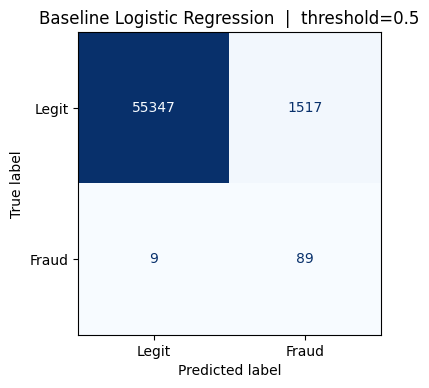

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Legit', 'Fraud']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Baseline Logistic Regression  |  threshold={THRESHOLD}')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. PR curve and ROC curve

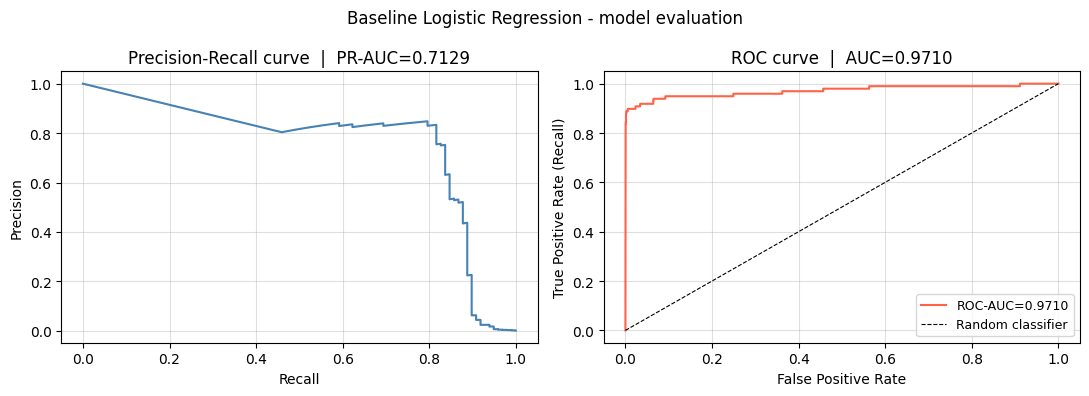

In [7]:
prec_curve, rec_curve, _  = precision_recall_curve(y_test, y_prob)
fpr, tpr, __              = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(rec_curve, prec_curve, color='steelblue', lw=1.5)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall curve  |  PR-AUC={prauc:.4f}')
axes[0].grid(True, alpha=0.4)

axes[1].plot(fpr, tpr, color='tomato', lw=1.5, label=f'ROC-AUC={rocauc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=0.8, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title(f'ROC curve  |  AUC={rocauc:.4f}')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

plt.suptitle('Baseline Logistic Regression - model evaluation', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save model and scaler

In [8]:
joblib.dump(lr,     MODELS_PATH / 'baseline_lr.joblib')
joblib.dump(scaler, MODELS_PATH / 'baseline_scaler.joblib')
print("Saved: outputs/models/baseline_lr.joblib")
print("Saved: outputs/models/baseline_scaler.joblib")

Saved: outputs/models/baseline_lr.joblib
Saved: outputs/models/baseline_scaler.joblib


## 8. Summary

In [9]:
baseline_results = {
    'model'    : 'LogisticRegression (balanced)',
    'threshold': THRESHOLD,
    'pr_auc'   : prauc,
    'roc_auc'  : rocauc,
    'precision': prec,
    'recall'   : rec,
    'f1'       : f1,
}

print("=" * 55)
print("BASELINE RESULTS")
print("=" * 55)
for k, v in baseline_results.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")
print(f"\n  Fraud caught  : {tp} / {y_test.sum()} ({tp/y_test.sum()*100:.1f}%)")
print(f"  Fraud missed  : {fn}")
print(f"  False alarms  : {fp}")
print(f"\nNext: notebook 03 - tackle class imbalance with SMOTE and resampling.")
print(f"Target to beat: PR-AUC {prauc:.4f}")
print("=" * 55)

BASELINE RESULTS
  model               : LogisticRegression (balanced)
  threshold           : 0.5000
  pr_auc              : 0.7129
  roc_auc             : 0.9710
  precision           : 0.0554
  recall              : 0.9082
  f1                  : 0.1045

  Fraud caught  : 89 / 98 (90.8%)
  Fraud missed  : 9
  False alarms  : 1517

Next: notebook 03 - tackle class imbalance with SMOTE and resampling.
Target to beat: PR-AUC 0.7129
